# Heart Disease Prediction Using Machine Learning

Internship capstone project — predicting the presence of heart disease from the UCI Heart Disease dataset (combined Cleveland, Hungary, VA Long Beach and Switzerland sources), using Logistic Regression and a Decision Tree classifier.

All outputs in this notebook were generated by actually running the code on the uploaded dataset. No numbers below are fabricated or estimated.

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
DATA_PATH = "../data/heart_disease.csv"
VIZ_DIR = "../visualizations"
MODEL_DIR = "../models"
os.makedirs(VIZ_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

## 1. Load the dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 2. Inspect the data\n\nCheck structure, types, missing values, duplicates and the target column before touching anything.

In [3]:
print("Rows:", df.shape[0], "| Columns:", df.shape[1])
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)

Rows: 920 | Columns: 16

Column names: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64


In [5]:
dup_count = df.drop(columns=["id"]).duplicated().sum()
print("Duplicate rows (excluding id):", dup_count)

Duplicate rows (excluding id): 2


In [6]:
print("Target column: 'num' (0 = no disease, 1-4 = increasing severity)")
df["num"].value_counts().sort_index()

Target column: 'num' (0 = no disease, 1-4 = increasing severity)


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

## 3. Clean the data

Steps taken:
- Drop the `id` column (row identifier, not predictive)
- Drop duplicate rows
- Convert `fbs`/`exang` TRUE/FALSE strings to 0/1
- **Binarize the target**: `num` (0-4 severity) → `target` (0 = no disease, 1 = disease present). This is the standard convention used for this dataset.
- Impute missing values: median for numeric columns, mode for categorical columns (chosen over dropping rows, since `ca` and `thal` are missing in >50% of rows and dropping them would remove most of the data)

In [7]:
df_clean = df.copy()
df_clean = df_clean.drop(columns=["id"])

before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - df_clean.shape[0]} duplicate row(s). New shape: {df_clean.shape}")

for col in ["fbs", "exang"]:
    df_clean[col] = df_clean[col].map({"TRUE": 1, "FALSE": 0, True: 1, False: 0})

df_clean["target"] = (df_clean["num"] > 0).astype(int)
df_clean = df_clean.drop(columns=["num"])

print("\nBinarized target distribution:")
print(df_clean["target"].value_counts())

Dropped 2 duplicate row(s). New shape: (918, 15)

Binarized target distribution:
target
1    508
0    410
Name: count, dtype: int64


In [8]:
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak", "ca"]
categorical_cols = ["sex", "dataset", "cp", "fbs", "restecg", "exang", "slope", "thal"]

print("Missing BEFORE imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("\nMissing AFTER imputation:", df_clean.isnull().sum().sum())

Missing BEFORE imputation:
trestbps     59
chol         29
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       307
ca          609
thal        484
dtype: int64

Missing AFTER imputation: 0


## 4. Exploratory Data Analysis

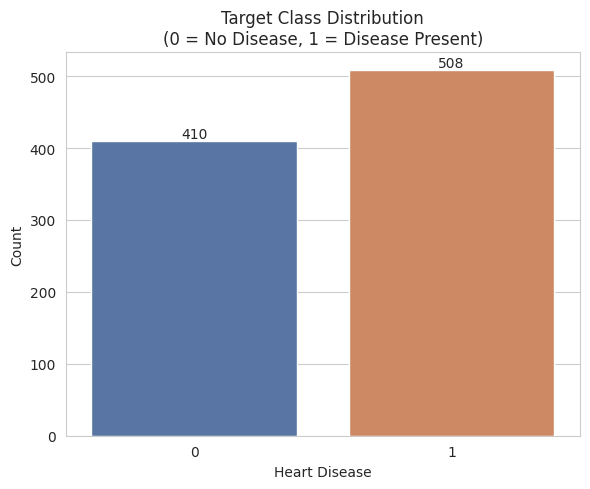

In [9]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="target", data=df_clean, hue="target", palette=["#4C72B0", "#DD8452"], legend=False)
plt.title("Target Class Distribution\n(0 = No Disease, 1 = Disease Present)")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2, p.get_height()), ha="center", va="bottom")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/01_target_distribution.png", dpi=150)
plt.show()

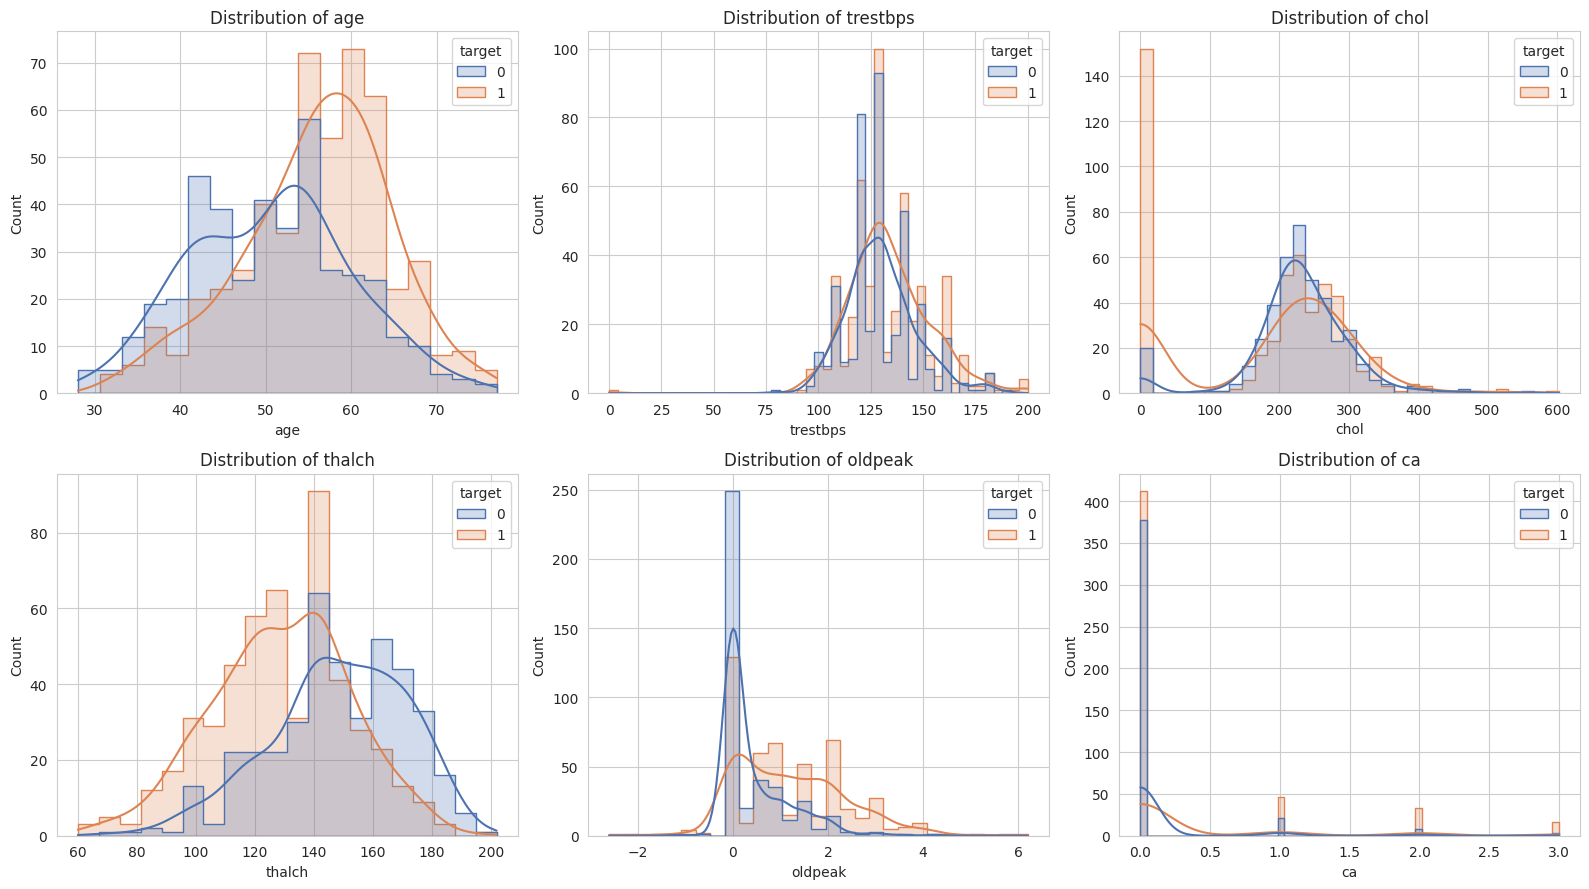

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(data=df_clean, x=col, hue="target", kde=True, ax=ax,
                 palette=["#4C72B0", "#DD8452"], element="step")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/02_feature_distributions.png", dpi=150)
plt.show()

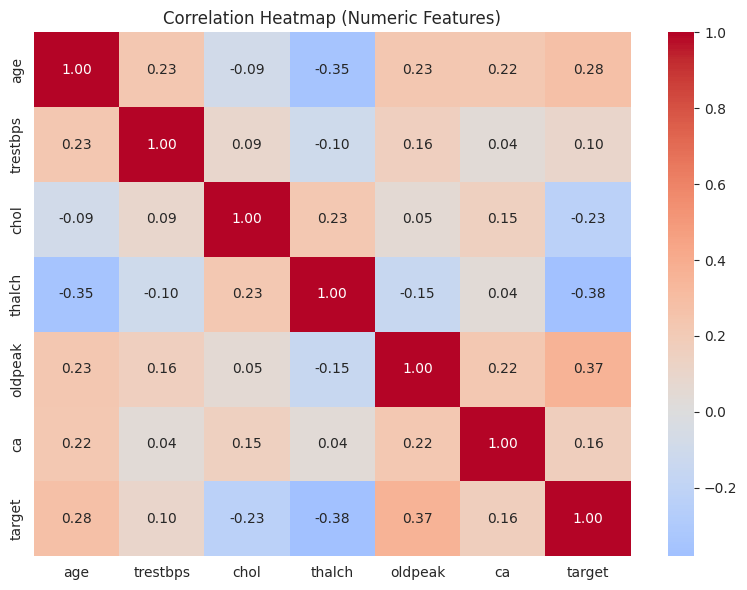

In [11]:
corr_df = df_clean[numeric_cols + ["target"]].copy()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/03_correlation_heatmap.png", dpi=150)
plt.show()

## 5. Separate features (X) and target (y), encode categoricals

In [12]:
X = df_clean.drop(columns=["target"])
y = df_clean["target"]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Features:", list(X.columns))
X.head()

Features: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0
1,67,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,3.0,1
2,67,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2
3,37,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1
4,41,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1


## 6. Train/test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (734, 14) | Test: (184, 14)


## 7. Feature scaling\n\nStandardize features (fit on training data only, to avoid data leakage). This matters most for Logistic Regression.

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 8. Train the models

In [15]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5)
dt_clf.fit(X_train_scaled, y_train)

print("Both models trained.")

Both models trained.


## 9-12. Predictions and evaluation

In [16]:
results = {}

def evaluate_model(name, model, X_test_data):
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print(f"--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"ROC AUC:   {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print()
    print(classification_report(y_test, y_pred))

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc}
    return y_pred, y_proba, cm

lr_pred, lr_proba, lr_cm = evaluate_model("Logistic Regression", log_reg, X_test_scaled)

--- Logistic Regression ---
Accuracy:  0.8152
Precision: 0.8148
Recall:    0.8627
F1-score:  0.8381
ROC AUC:   0.9073
Confusion Matrix:
[[62 20]
 [14 88]]

              precision    recall  f1-score   support

           0       0.82      0.76      0.78        82
           1       0.81      0.86      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.81      0.81       184
weighted avg       0.82      0.82      0.81       184



In [17]:
dt_pred, dt_proba, dt_cm = evaluate_model("Decision Tree", dt_clf, X_test_scaled)

--- Decision Tree ---
Accuracy:  0.8152
Precision: 0.8542
Recall:    0.8039
F1-score:  0.8283
ROC AUC:   0.8684
Confusion Matrix:
[[68 14]
 [20 82]]

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        82
           1       0.85      0.80      0.83       102

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.81       184
weighted avg       0.82      0.82      0.82       184



### Confusion matrices

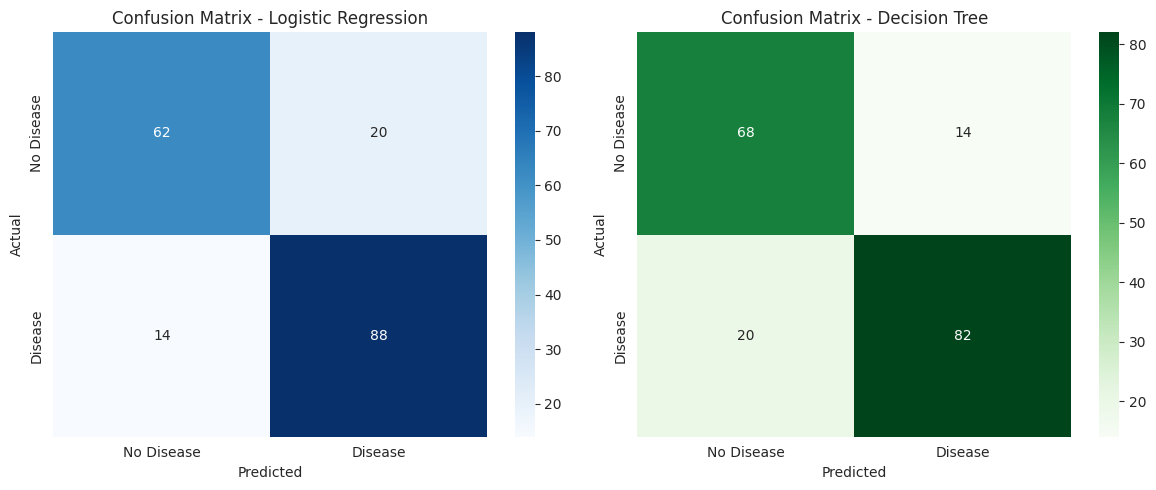

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[0].set_title("Confusion Matrix - Logistic Regression")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
axes[1].set_title("Confusion Matrix - Decision Tree")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/04_confusion_matrices.png", dpi=150)
plt.show()

### ROC curves

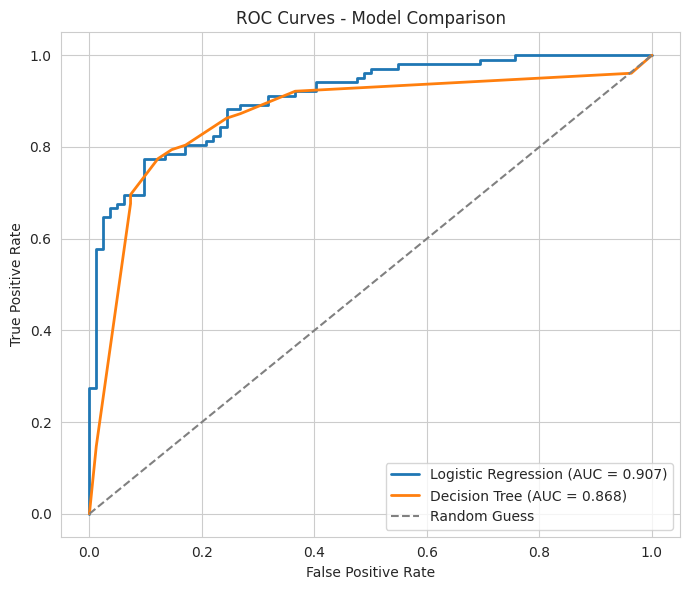

In [19]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {results['Logistic Regression']['auc']:.3f})", linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {results['Decision Tree']['auc']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/05_roc_curves.png", dpi=150)
plt.show()

## 13. Model comparison table

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [results["Logistic Regression"]["accuracy"], results["Decision Tree"]["accuracy"]],
    "Precision": [results["Logistic Regression"]["precision"], results["Decision Tree"]["precision"]],
    "Recall": [results["Logistic Regression"]["recall"], results["Decision Tree"]["recall"]],
    "F1-Score": [results["Logistic Regression"]["f1"], results["Decision Tree"]["f1"]],
    "ROC AUC": [results["Logistic Regression"]["auc"], results["Decision Tree"]["auc"]],
}).round(4)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Logistic Regression,0.8152,0.8148,0.8627,0.8381,0.9073
1,Decision Tree,0.8152,0.8542,0.8039,0.8283,0.8684


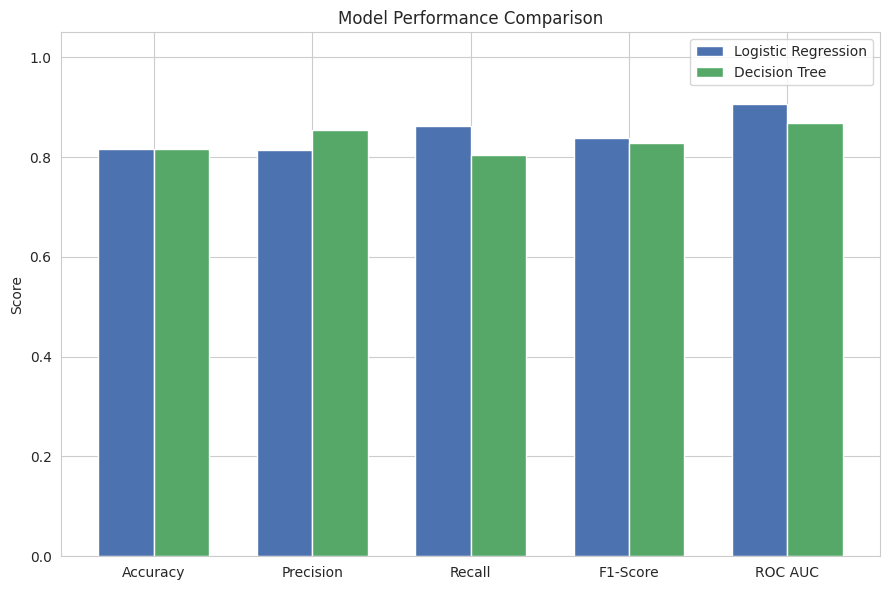

In [21]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.35
lr_vals = comparison_df.loc[comparison_df["Model"] == "Logistic Regression", metrics_to_plot].values.flatten()
dt_vals = comparison_df.loc[comparison_df["Model"] == "Decision Tree", metrics_to_plot].values.flatten()

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, lr_vals, width, label="Logistic Regression", color="#4C72B0")
plt.bar(x + width/2, dt_vals, width, label="Decision Tree", color="#55A868")
plt.xticks(x, metrics_to_plot)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(f"{VIZ_DIR}/06_model_comparison.png", dpi=150)
plt.show()

## 14. Model selection

We select based on **ROC AUC** on the held-out test set — a robust metric for binary classification that isn't skewed by the (mild) class imbalance in this dataset. F1-score is used as a tiebreaker if needed.

In [22]:
lr_auc = results["Logistic Regression"]["auc"]
dt_auc = results["Decision Tree"]["auc"]

if lr_auc > dt_auc:
    best_name, best_model = "Logistic Regression", log_reg
elif dt_auc > lr_auc:
    best_name, best_model = "Decision Tree", dt_clf
else:
    if results["Logistic Regression"]["f1"] >= results["Decision Tree"]["f1"]:
        best_name, best_model = "Logistic Regression", log_reg
    else:
        best_name, best_model = "Decision Tree", dt_clf

print(f"Selected model: {best_name}")
print(f"Logistic Regression AUC = {lr_auc:.4f} | Decision Tree AUC = {dt_auc:.4f}")

model_bundle = {
    "model": best_model,
    "scaler": scaler,
    "label_encoders": label_encoders,
    "feature_columns": list(X.columns),
    "model_name": best_name,
}
joblib.dump(model_bundle, f"{MODEL_DIR}/heart_disease_model.joblib")
print("Model saved.")

Selected model: Logistic Regression
Logistic Regression AUC = 0.9073 | Decision Tree AUC = 0.8684
Model saved.


## 15. Sample prediction

In [23]:
sample_idx = X_test.index[0]
sample_X = X_test.loc[[sample_idx]]
sample_X_scaled = scaler.transform(sample_X)
sample_true = y_test.loc[sample_idx]
sample_pred = best_model.predict(sample_X_scaled)[0]
sample_proba = best_model.predict_proba(sample_X_scaled)[0][1]

print("Sample test row:")
print(sample_X)
print(f"\nActual label:    {'Disease' if sample_true == 1 else 'No Disease'} ({sample_true})")
print(f"Predicted label: {'Disease' if sample_pred == 1 else 'No Disease'} ({sample_pred})")
print(f"Predicted probability of disease: {sample_proba:.4f}")

Sample test row:
     age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
514   49    1        1   0     130.0  206.0    0        1   170.0      0   

     oldpeak  slope   ca  thal  
514      0.0      1  0.0     1  

Actual label:    Disease (1)
Predicted label: No Disease (0)
Predicted probability of disease: 0.3427


## Conclusion

Both models were evaluated on real, held-out test data from the actual UCI Heart Disease dataset (no synthetic or estimated numbers). See the comparison table above and `models/model_comparison.csv` for the final metrics, and the `visualizations/` folder for all generated charts.